# 01. Exploratory Data Analysis
**Goal:** understand the data before modeling. We only *look* at the data here. No scaling, resampling or splitting happens in this notebook, so there is no leakage risk.
We set a fixed seed (42) and import our reusable loader from `src/`.

In [4]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Make `src` importable when the notebook runs from notebooks/
sys.path.append(str(Path.cwd().parent))

from src.data_loader import PCA_COLUMNS, TARGET_COLUMN, load_data  # noqa: E402

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

## 1. Load and validate
`load_data` checks the schema, so if the file is wrong or incomplete we fail here instead of deep in the analysis.

In [5]:
df = load_data()

Shape: 284,807 rows x 31 columns
Memory usage: 67.36 MB

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64


## 2. First look
We check the size, types, a few rows and summary statistics. Things to notice: all features are numeric, `V1-V28` are PCA components (roughly zero-centered), and `Time` and `Amount` are the only features on their original (unscaled) units. That is why they will need scaling later, *after* the train/test split.

In [6]:
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes.value_counts())

display(df.head())
display(df.describe().T.round(3))

Shape: (284807, 31)

Dtypes:
float64    30
int64       1
Name: count, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,94813.860,47488.146,0.000,54201.500,84692.000,139320.500,172792.000
V1,284807.0,0.000,1.959,-56.408,-0.920,0.018,1.316,2.455
V2,284807.0,0.000,1.651,-72.716,-0.599,0.065,0.804,22.058
V3,284807.0,-0.000,1.516,-48.326,-0.890,0.180,1.027,9.383
V4,284807.0,0.000,1.416,-5.683,-0.849,-0.020,0.743,16.875
V5,284807.0,0.000,1.380,-113.743,-0.692,-0.054,0.612,34.802
V6,284807.0,0.000,1.332,-26.161,-0.768,-0.274,0.399,73.302
V7,284807.0,-0.000,1.237,-43.557,-0.554,0.040,0.570,120.589
V8,284807.0,0.000,1.194,-73.217,-0.209,0.022,0.327,20.007
V9,284807.0,-0.000,1.099,-13.434,-0.643,-0.051,0.597,15.595


## 3. Data quality: missing values and duplicates
Missing values determine whether we need imputation. Duplicate rows matter because if copies of the same transaction land in both train and test sets, evaluation becomes over-optimistic. We **only count** duplicates here. The decision to drop them is made in Stage 2, before splitting.

In [7]:
print("Total missing values:", int(df.isna().sum().sum()))

dup_mask = df.duplicated()
n_dup = int(dup_mask.sum())
print(f"Duplicate rows: {n_dup:,} ({n_dup / len(df):.3%} of data)")
print("\nClass breakdown of duplicates:")
print(df.loc[dup_mask, TARGET_COLUMN].value_counts())

Total missing values: 0
Duplicate rows: 1,081 (0.380% of data)

Class breakdown of duplicates:
Class
0    1062
1      19
Name: count, dtype: int64


## 4. Target distribution and imbalance
Fraud is the positive class (`Class=1`). We quantify how rare it is and plot the class counts. This imbalance will drive our choice of metrics and training strategy in Stage 2.

In [8]:
counts = df[TARGET_COLUMN].value_counts().sort_index()
percent = df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({"count": counts, "percent": percent.round(4)})
summary.index = ["Legit (0)", "Fraud (1)"]
display(summary)

print(f"Imbalance ratio: 1 fraud per {counts[0] / counts[1]:.0f} legit transactions")
print(f"Accuracy of 'always predict legit': {counts[0] / len(df):.4%}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, scale in zip(axes, ["linear", "log"]):
    sns.barplot(x=summary.index, y=summary["count"], ax=ax)
    ax.set_yscale(scale)
    ax.bar_label(ax.containers[0], fmt="%d")
    ax.set_title(f"Class counts ({scale} scale)")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

,count,percent
Legit (0),284315,99.8273
Fraud (1),492,0.1727


Imbalance ratio: 1 fraud per 578 legit transactions
Accuracy of 'always predict legit': 99.8273%


<Figure size 1100x400 with 2 Axes>

### 5. Transaction amount

Amount is heavily right-skewed: most transactions are small and a few are very large. We compare fraud vs. legit using summary stats, a log-scaled view (`log1p` handles zero amounts) and IQR-based outlier counts. Outliers are *not* automatically errors here. Large legitimate purchases are real, so we avoid blindly removing them.

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
Fraud,492.0,122.21,256.68,0.0,1.00,9.25,105.89,2125.87
Legit,284315.0,88.29,250.11,0.0,5.65,22.00,77.05,25691.16


Zero-amount transactions: 1825


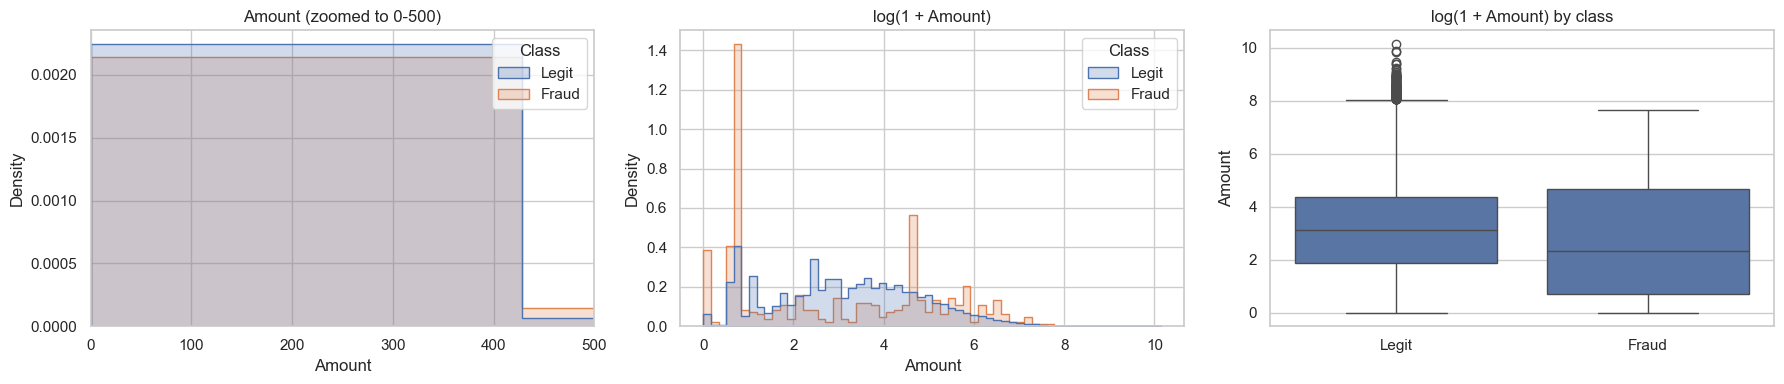

,upper_fence,n_outliers,pct_outliers,max_amount
Class,,,,
Fraud,263.23,69.0,14.02,2125.87
Legit,184.15,31862.0,11.21,25691.16


In [9]:
label = df[TARGET_COLUMN].map({0: "Legit", 1: "Fraud"})

display(df.groupby(label)["Amount"].describe().round(2))
print("Zero-amount transactions:", int((df["Amount"] == 0).sum()))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(
    x=df["Amount"], hue=label, bins=60, stat="density",
    common_norm=False, element="step", ax=axes[0],
)
axes[0].set_xlim(0, 500)
axes[0].set_title("Amount (zoomed to 0-500)")

sns.histplot(
    x=np.log1p(df["Amount"]), hue=label, bins=60, stat="density",
    common_norm=False, element="step", ax=axes[1],
)
axes[1].set_title("log(1 + Amount)")

sns.boxplot(x=label, y=np.log1p(df["Amount"]), ax=axes[2])
axes[2].set_title("log(1 + Amount) by class")
axes[2].set_xlabel("")
plt.tight_layout()
plt.show()


def iqr_outlier_summary(series: pd.Series) -> pd.Series:
    """Return IQR upper fence, outlier count/percent and max for a series."""
    q1, q3 = series.quantile([0.25, 0.75])
    upper = q3 + 1.5 * (q3 - q1)
    is_outlier = series > upper
    return pd.Series({
        "upper_fence": upper,
        "n_outliers": int(is_outlier.sum()),
        "pct_outliers": is_outlier.mean() * 100,
        "max_amount": series.max(),
    })


display(df.groupby(label)["Amount"].apply(iqr_outlier_summary).unstack().round(2))

### 6. Time analysis

`Time` is the number of seconds since the *first* transaction in the dataset (it spans about 48 hours). It is not a real clock time, so `(Time // 3600) % 24` gives an hour-of-day *offset* that is only a proxy. We compare fraud **rate** per hour, not raw fraud counts, because transaction volume varies a lot by hour. Note that at night there are few transactions and few frauds, so rates are noisy. Treat patterns as hints, not conclusions.

Time span: 48.0 hours


,transactions,frauds,fraud_rate_pct
Hour,,,
0,7695,6,0.078
1,4220,10,0.237
2,3328,57,1.713
3,3492,17,0.487
4,2209,23,1.041
5,2990,11,0.368
6,4101,9,0.219
7,7243,23,0.318
8,10276,9,0.088


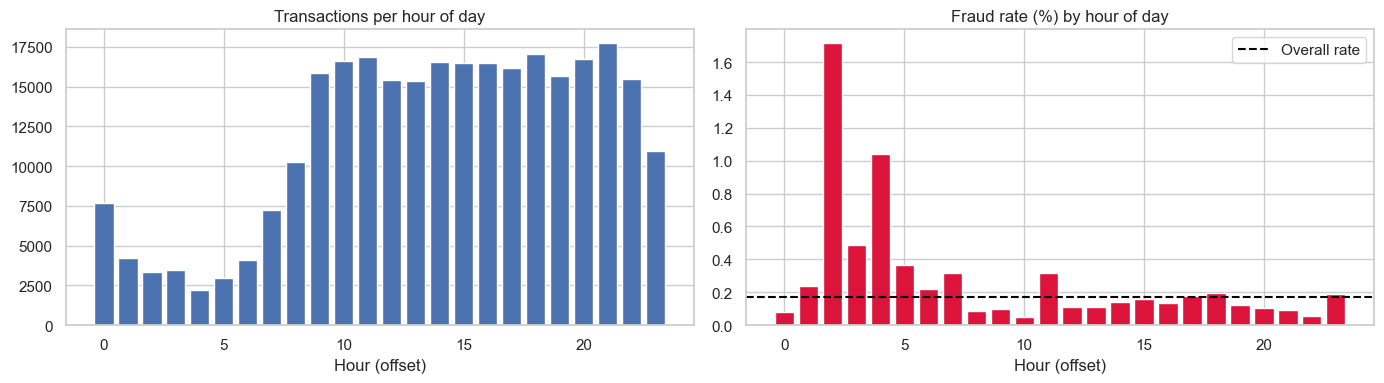

In [10]:
print(f"Time span: {df['Time'].max() / 3600:.1f} hours")

hour = ((df["Time"] // 3600) % 24).astype(int).rename("Hour")
hourly = df[TARGET_COLUMN].groupby(hour).agg(transactions="count", frauds="sum")
hourly["fraud_rate_pct"] = hourly["frauds"] / hourly["transactions"] * 100
display(hourly.round(3))

overall_rate = df[TARGET_COLUMN].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(hourly.index, hourly["transactions"])
axes[0].set_title("Transactions per hour of day")
axes[0].set_xlabel("Hour (offset)")

axes[1].bar(hourly.index, hourly["fraud_rate_pct"], color="crimson")
axes[1].axhline(overall_rate, color="black", linestyle="--", label="Overall rate")
axes[1].set_title("Fraud rate (%) by hour of day")
axes[1].set_xlabel("Hour (offset)")
axes[1].legend()
plt.tight_layout()
plt.show()

### 7. Correlation with `Class`

The heatmap shows pairwise correlations. Because `V1-V28` come from PCA, they are mutually near-uncorrelated, so the heatmap is mostly blank among them. Correlation with `Class` shows which features separate fraud best. Caveat: Pearson correlation with a rare binary target only captures *linear* relationships, so use it as a guide, not a final feature selection. Also, any real feature selection later must be done on the **training set only**.

,corr_with_class
V17,-0.326
V14,-0.303
V12,-0.261
V10,-0.217
V16,-0.197
V3,-0.193
V7,-0.187
V11,0.155
V4,0.133
V18,-0.111


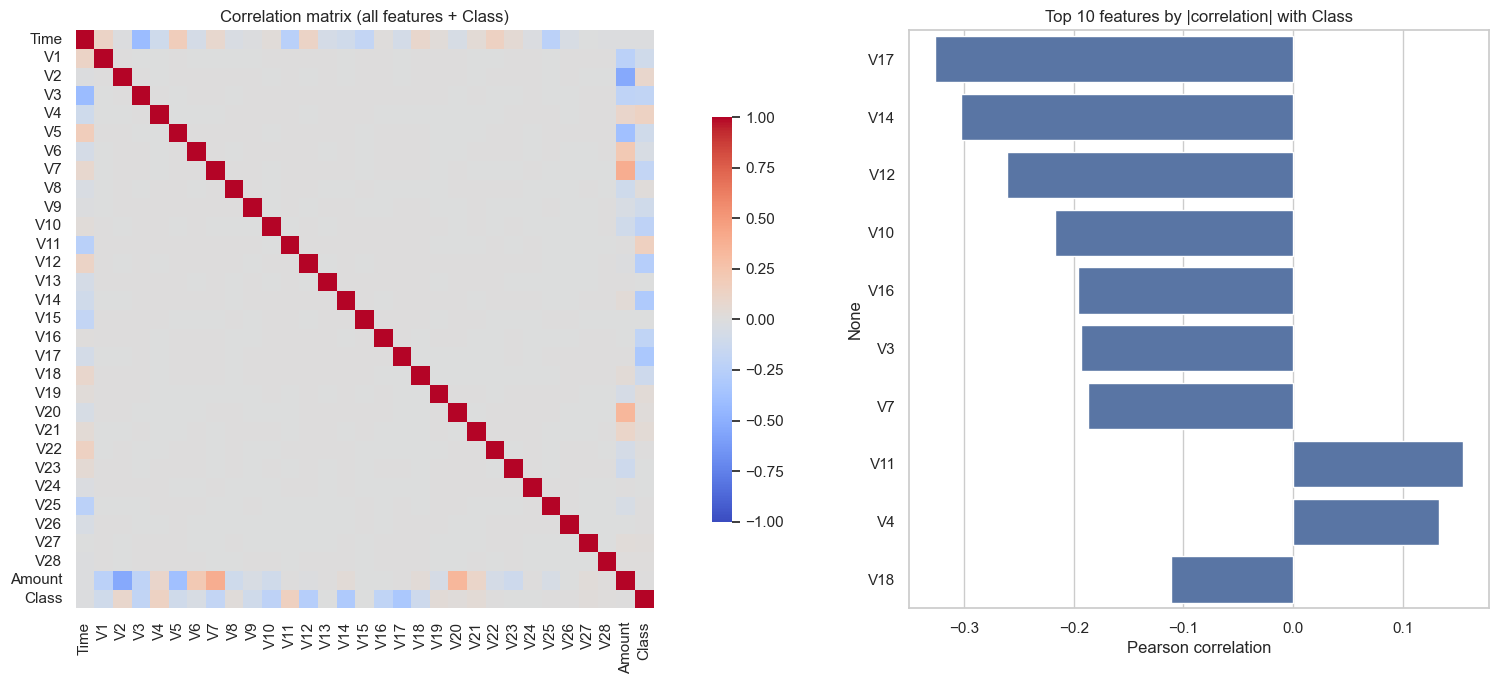

In [12]:
corr = df.corr()

class_corr = corr[TARGET_COLUMN].drop(TARGET_COLUMN)
top10 = class_corr.reindex(class_corr.abs().sort_values(ascending=False).index).head(10)
TOP_FEATURES = top10.index.tolist()

display(top10.round(3).to_frame("corr_with_class"))

fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={"width_ratios": [2, 1]})
sns.heatmap(
    corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
    square=True, cbar_kws={"shrink": 0.7}, ax=axes[0],
)
axes[0].set_title("Correlation matrix (all features + Class)")

sns.barplot(x=top10.values, y=top10.index, ax=axes[1])
axes[1].set_title("Top 10 features by |correlation| with Class")
axes[1].set_xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

### 8. Fraud vs. legit distributions for the top features

If the fraud curve is clearly shifted or shaped differently from the legit curve, that feature has predictive power. `common_norm=False` normalizes each class separately. Without it, the 0.17% fraud curve would be invisible.

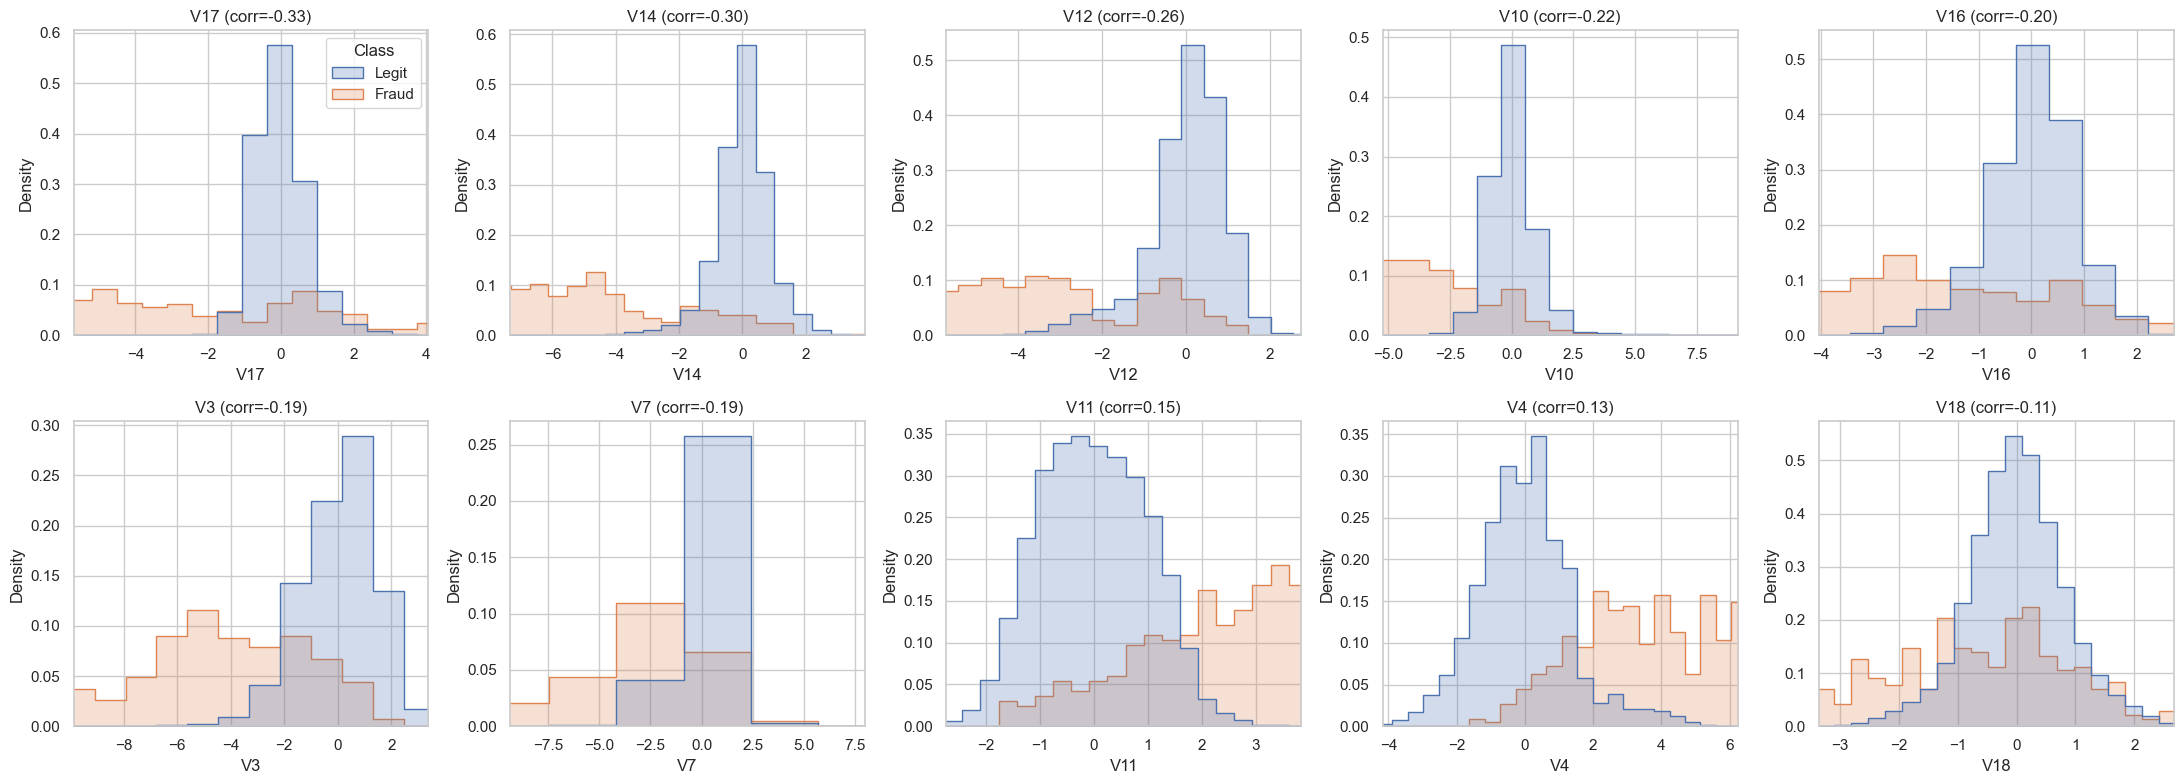

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))

for i, (ax, feat) in enumerate(zip(axes.ravel(), TOP_FEATURES)):
    sns.histplot(
        data=df, x=feat, hue=label, bins=50, stat="density",
        common_norm=False, element="step", ax=ax, legend=(i == 0),
    )
    low, high = df[feat].quantile([0.001, 0.999])
    ax.set_xlim(low, high)
    ax.set_title(f"{feat} (corr={class_corr[feat]:.2f})")

plt.tight_layout()
plt.show()

## Key EDA findings

1. **Severe imbalance:** 492 frauds in 284,807 transactions (0.1727%), about 1 fraud per 578 legit. A classifier that always predicts legit achieves 99.8273% accuracy, showing why accuracy is misleading. Use precision, recall, F1 and PR-AUC.

2. **Clean data:** no missing values were found. Duplicate rows were counted during EDA and will be handled before splitting in Stage 2.

3. **Amount is highly skewed:** most transactions are small. The median fraud amount is 9.25 compared with 22.00 for legitimate transactions. There are 1,825 zero-amount transactions. Large legitimate transactions exist, so outliers should not be blindly removed.

4. **Time is a weak, noisy signal:** the hourly fraud rate varies, but low-volume hours can produce unstable rates. `Time` is a relative offset from the first transaction, not a clock time.

5. **A handful of PCA features carry most of the signal:** the strongest correlations with `Class` are observed for features such as V17, V14, V12, V10, V16, V3, V7, V11, V4 and V18. Their fraud and legitimate distributions are visibly different.

6. **V1-V28 are mostly uncorrelated with each other:** this is expected because they are PCA-derived features, so multicollinearity is not a major concern among these features.

7. **Implication for modeling:** use a stratified train/test split, apply scaling and resampling only on training data, and evaluate models using PR-AUC, recall, precision and F1.